# 1.Business Understanding

**Contexto**: En la industria de las telecomunicaciones, la retención de clientes es un factor crítico para la rentabilidad, ya que el coste de adquirir un nuevo usuario suele ser significativamente mayor que el de mantener a uno existente. El presente proyecto se basa en el conjunto de datos "Telco Customer Churn" (proporcionado por IBM), el cual contiene información detallada sobre el comportamiento de los clientes de una compañía de telecomunicaciones.

**Objetivo de Negocio**: Predecir qué clientes tienen una alta probabilidad de abandonar la compañía (Churn) para poder adelantarse y aplicar estrategias proactivas de retención (ofertas, mejoras de servicio).

**Objetivos de Minería de Datos**:

Construir un modelo de clasificación capaz de predecir la variable objetivo (Churn).

Identificar qué variables (patrones de uso, demografía o facturación) influyen más en la fuga de clientes.

Naturaleza de los Datos: El dataset de IBM analiza a los clientes a través de cuatro grandes bloques de información:

Demográficos: Género, edad, convivientes.

Servicios Contratados: Telefonía, internet, seguridad, streaming.

Datos de la Cuenta: Antigüedad, tipo de contrato, facturación y pagos.

Variable Objetivo (Target): Churn (indica si el cliente se dio de baja el mes pasado).

# 2. Data Understanding

## 1.Análisis General de los datos

In [1]:
import pandas as pd

# Cargar el dataset desde el archivo CSV
data = pd.read_csv('../data/Telco-Customer-Churn.csv')

# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Visualizar las primeras filas del dataset omitiendo las filas que tienen más de un NaN
data.dropna(thresh=data.shape[1] - 1).head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Realizar una descripción inicial del dataset
data.info()  # Información general de las columnas, tipos de datos y no nulos

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Hay un total de **21 variables** (incluyendo la variable objetivo **churn** y un volumen de **7043 registros**. En cuanto a los datos a simple vista, parece que no existen valores nulos y que la mayoría de los datos son categóricos (str).
Sin embargo, cabe destacar una **anomalía** en la variable **TotalCharges**: a pesar de representar una cantidad económica, aparece clasificada como **texto (str)** en lugar de **numérica (float64)**.
El identificador del cliente **(customerID)** no aporta ningún patrón predictivo. El identificador del cliente **(customerID)** no aporta ningún patrón predictivo.


In [3]:
# Eliminar la columna customerID porque no aporta información predictiva
data.drop(['customerID'], axis=1, inplace=True)

# Convertir TotalCharges a numérico. Los espacios en blanco se convertirán en NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Verificamos que el cambio se ha hecho correctamente
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## 1.2 Análisis Univariante 
Pasamos ahora a estudiar con más detalle las variables del dataset.

### Estadística Descriptiva

In [4]:
# Estadísticas descriptivas (media, std, min, max, etc.)
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


Teniendo solo a las 4 variables a estudiar numéricas, muestras las siguientes cosas

- **SeniorCitizen**: Trata de una variable binaria (0 = No Senior, 1 = Senior). Como indica la media el 16% de los clientes son de la tercera edad.
- **Tenure**: Mide los meses de permanencia del cliente. Sus valores oscilan entre 0 y 72 meses(6 años), por lógica se puede descartar la presencia de Outliers expremos. La media se sitúa en 32.3 meses y la mediana en 29, mostrando una ligera asimetría. Destaca su alta desviación estándar (24.5 meses), lo que indica una gran dispersión en la base de clientes: tenemos un volumen muy importante de usuarios recientes (el 25% lleva 9 meses o menos) conviviendo con un grupo muy sólido de clientes leales (el 25% superior lleva más de 55 meses).
- **MontlyCharges**: Representa la cuota mensual. Oscila entre 18.25 y 118.75, un rango coherente que refleja la diferencia entre servicios básicos y paquetes premium. La mediana (70.35) supera a la media (64.76), indicando un grupo significativo de usuarios con tarifas bajas.
- **TotalCharges**: Mide el valor acumulado del cliente. El recuento de registros (7032) confirma la exclusión de los 11 valores nulos detectados previamente. Presenta una altísima desviación típica (2266.7) y una media (2283.3) muy superior a su mediana (1397.4). Este fuerte sesgo positivo se debe a que hereda la alta variabilidad de la variable tenure; unos pocos clientes muy veteranos acumulan cargos totales extremadamente altos que distorsionan el promedio general.


### Análisis de Variables Numéricas
Pasamos ahora a estudiar con más detalle las variables numéricas del dataset.

**Diagrama de barras**

Variables numéricas:  <ArrowStringArray>
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Length: 4, dtype: str


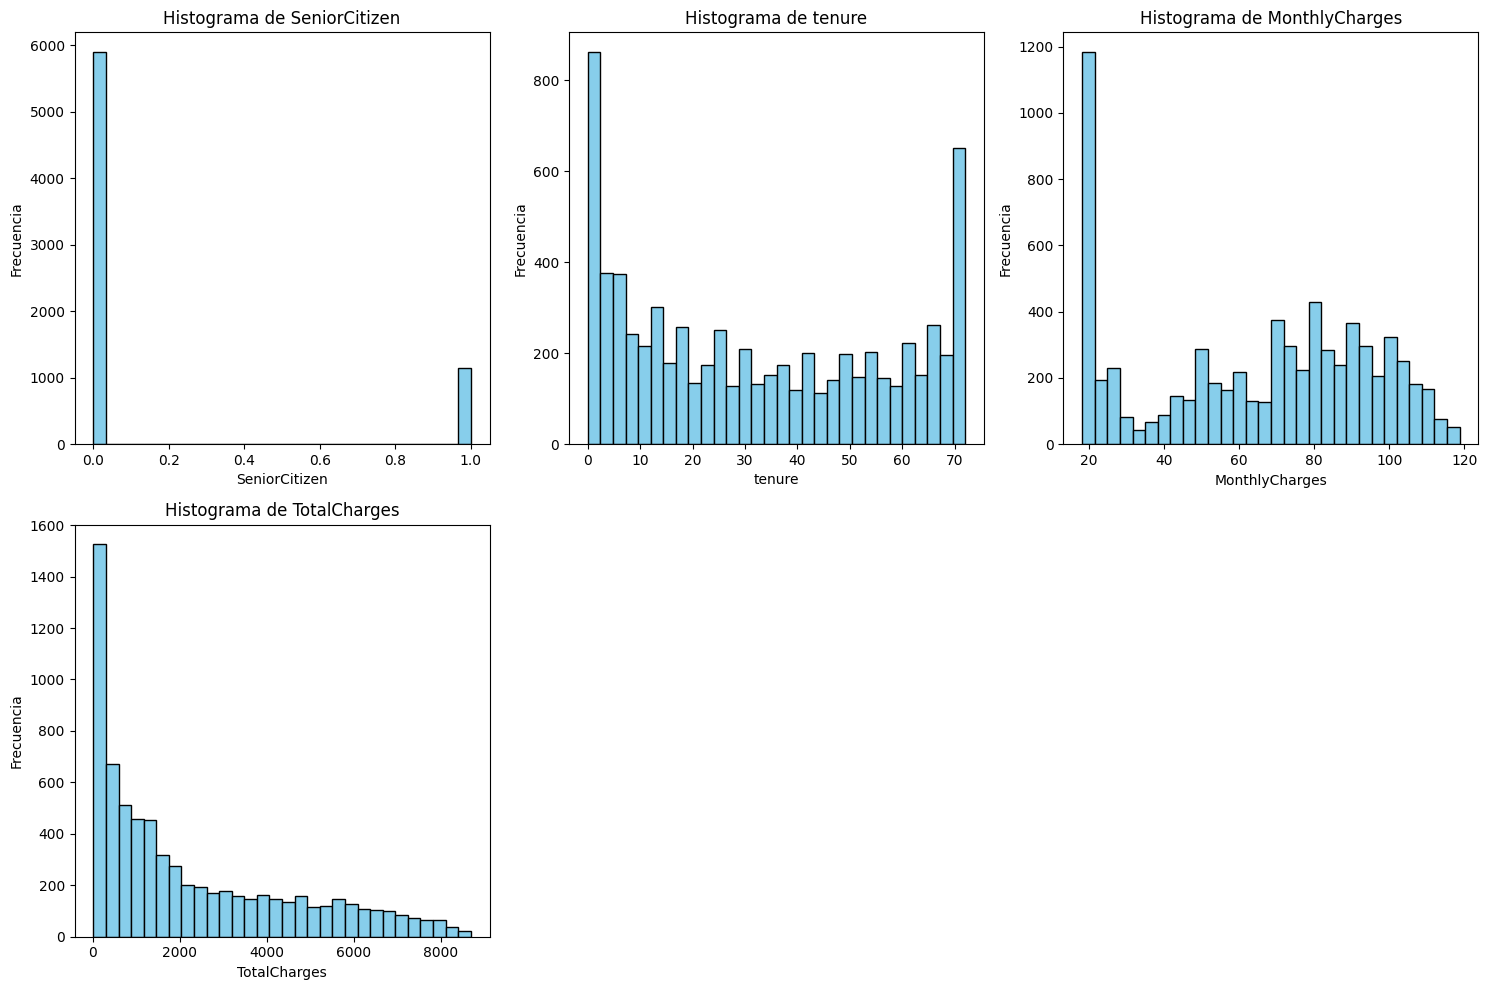

In [5]:
# Identificar las columnas numéricas
import numpy as np
import matplotlib.pyplot as plt

numeric_columns = data.select_dtypes(include=[np.number]).columns
print("Variables numéricas: ", numeric_columns.values)

# Crear una figura con subplots
num_vars = len(numeric_columns)
fig, axes = plt.subplots(nrows=(num_vars // 3) + 1, ncols=3, figsize=(15, 5 * ((num_vars // 3) + 1)))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    # Graficar el histograma
    axes[i].hist(data[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar ejes sobrantes si hay menos de 3 variables
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

**Diagrama de cajas(boxplot)**

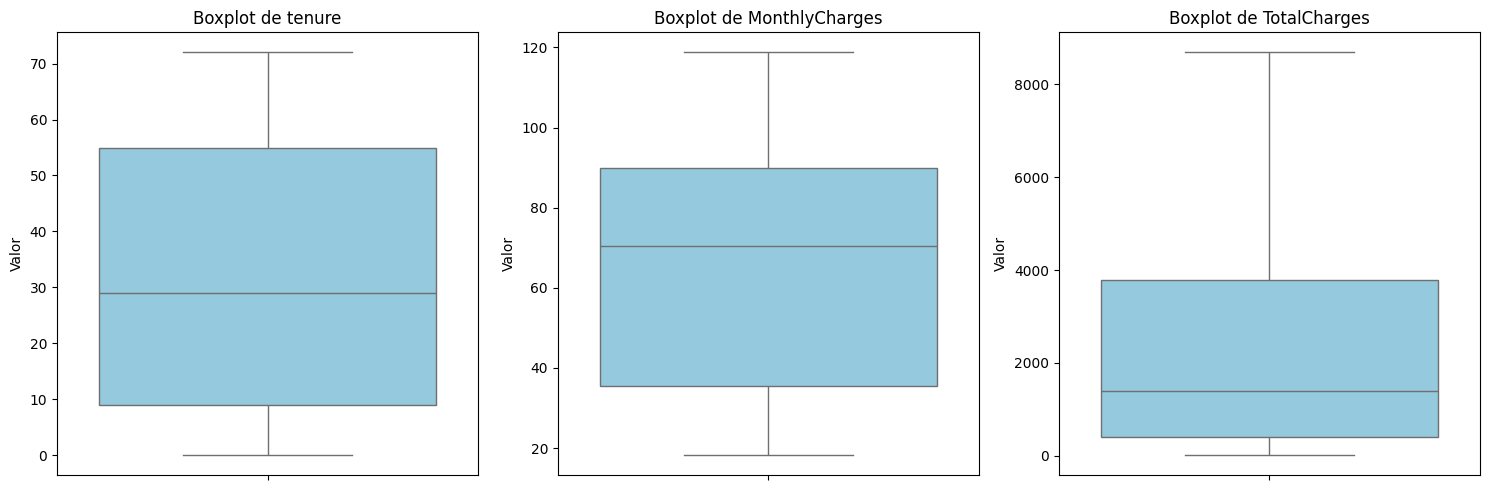

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las numéricas continuas
columnas_box = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Creamos el lienzo (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, col in enumerate(columnas_box):
    # sns.boxplot univariante (solo le pasamos el eje Y)
    sns.boxplot(y=data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

Como se observa en los dos diagramas, las variables numéricas no presentan valores atípicos (outliers).

### Análisis de variables categóricas
Pasamos ahora a estudiar con más detalle las variables categóricas del dataset.

In [7]:
# Identificar las variables categóricas
category_columns = data.select_dtypes(include=['object', 'category', 'str']).columns
print("Variables categóricas: ", category_columns.values)

# Calcular la cardinalidad de cada columna
cardinalities = data[category_columns].nunique()
print('\n',cardinalities.sort_values(ascending=False))

Variables categóricas:  <ArrowStringArray>
[          'gender',          'Partner',       'Dependents',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
            'Churn']
Length: 16, dtype: str

 PaymentMethod       4
OnlineBackup        3
InternetService     3
OnlineSecurity      3
TechSupport         3
StreamingTV         3
DeviceProtection    3
MultipleLines       3
StreamingMovies     3
Contract            3
Dependents          2
PhoneService        2
gender              2
Partner             2
PaperlessBilling    2
Churn               2
dtype: int64


In [8]:
# Identificar las variables categóricas
print("Variables categóricas: ", category_columns.values)

for column in category_columns:
    print(f"\nFrecuencia de la columna {column}:")
    print(data[column].value_counts())

Variables categóricas:  <ArrowStringArray>
[          'gender',          'Partner',       'Dependents',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
            'Churn']
Length: 16, dtype: str

Frecuencia de la columna gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Frecuencia de la columna Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Frecuencia de la columna Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Frecuencia de la columna PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Frecuencia de la columna MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Frecuencia de la columna InternetService:
InternetService
F

## 1.3 Análisis Bivariables

### Numérica vs Numérica

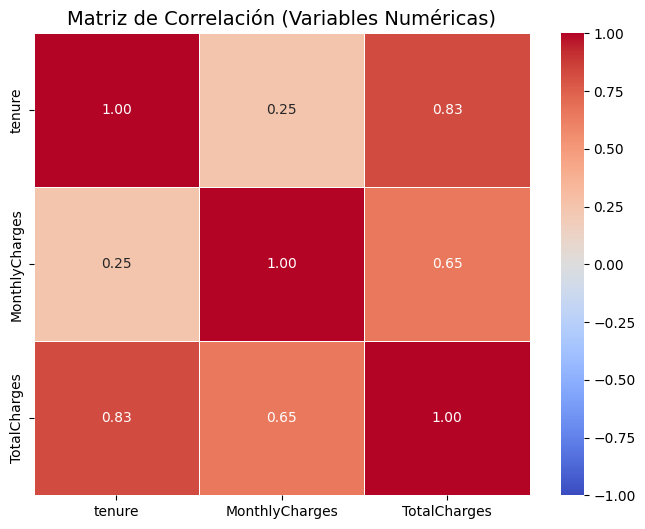

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las variables numéricas continuas
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
data_num = data[num_vars]

# 1. MATRIZ DE CORRELACIÓN (Numérica)
plt.figure(figsize=(8, 6))
correlacion = data_num.corr() # Calcula la crrelación de Pearson
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Variables Numéricas)', fontsize=14)
plt.show()

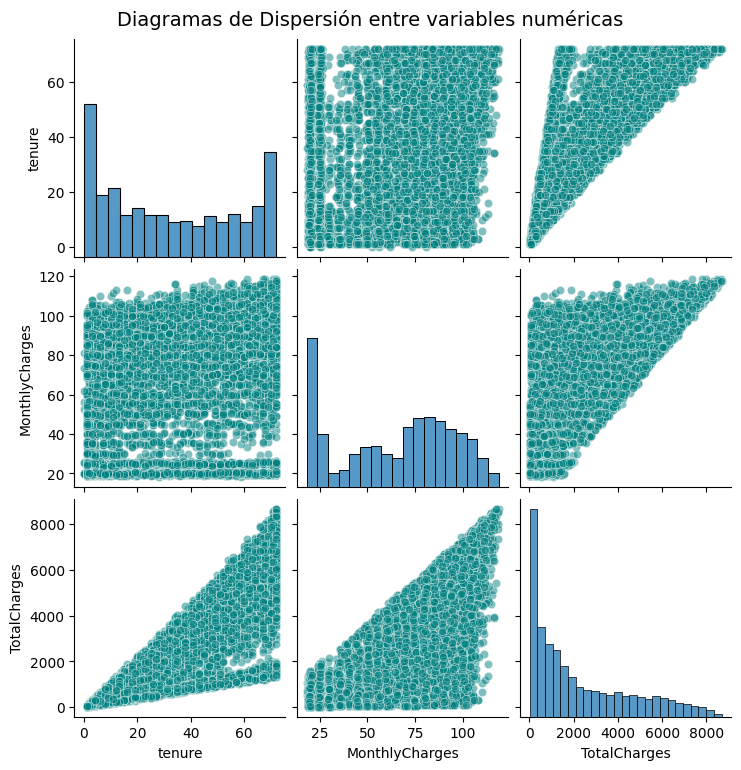

In [10]:
# 2. DIAGRAMAS DE DISPERSIÓN (Scatter plots)
sns.pairplot(data_num, kind='scatter', diag_kind='hist', plot_kws={'alpha':0.5, 'color':'teal'})
plt.suptitle('Diagramas de Dispersión entre variables numéricas', y=1.02, fontsize=14)
plt.show()

**Conclusiones** del Análisis Numérica vs. Numérica:

- La matriz de correlación de Pearson revela una fuerte relación lineal positiva (0.83) entre la antigüedad del cliente (tenure) y los cargos totales acumulados (TotalCharges).

- Esta correlación se confirma visualmente en los diagramas de dispersión, donde observamos una clara tendencia ascendente en forma de abanico. El ensanchamiento de la dispersión a mayor antigüedad refleja las diferencias en las cuotas mensuales de los distintos clientes.

### Numérica vs Categórica

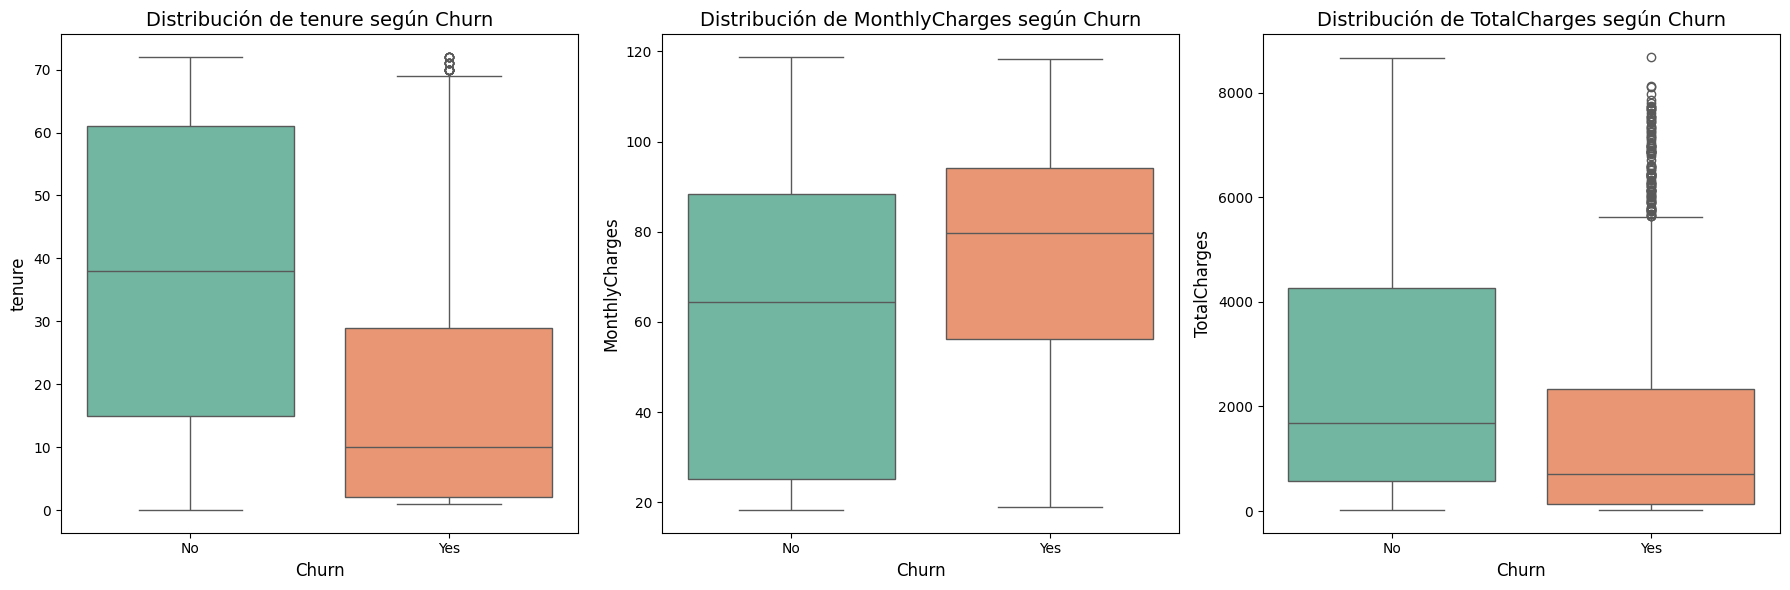

In [11]:
# Cruzamos las variables numéricas con la variable objetivo Categórica (Churn)

num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Creamos un lienzo con 1 fila y 3 columnas
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(num_vars):
    
    sns.boxplot(x='Churn', y=col, data=data, ax=axes[i], palette='Set2', hue='Churn', legend=False)
    
    axes[i].set_title(f'Distribución de {col} según Churn', fontsize=14)
    axes[i].set_xlabel('Churn', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

**Conclusiones** del Análisis Numérica vs. Categórica (Variable Objetivo Churn):
- **Ternure**: Hay un mayor riesgo de perder un cliente en su primer año. Una vez superado la probabilidad de quedarse es alta.
- **MonthlyChanges**: Los clientes con facturas más baratas son más fieles, y los clientes con facturas más altas son más propensos a irse.
- **TotalChanges**: La caja de los clientes que se dan de baja es muy baja porque abandonan la empresa antes de poder acumular un gasto alto. La caja de los clientes que se dan de baja es muy baja porque abandonan la empresa antes de poder acumular un gasto alto.

### Numérica vs Categórica

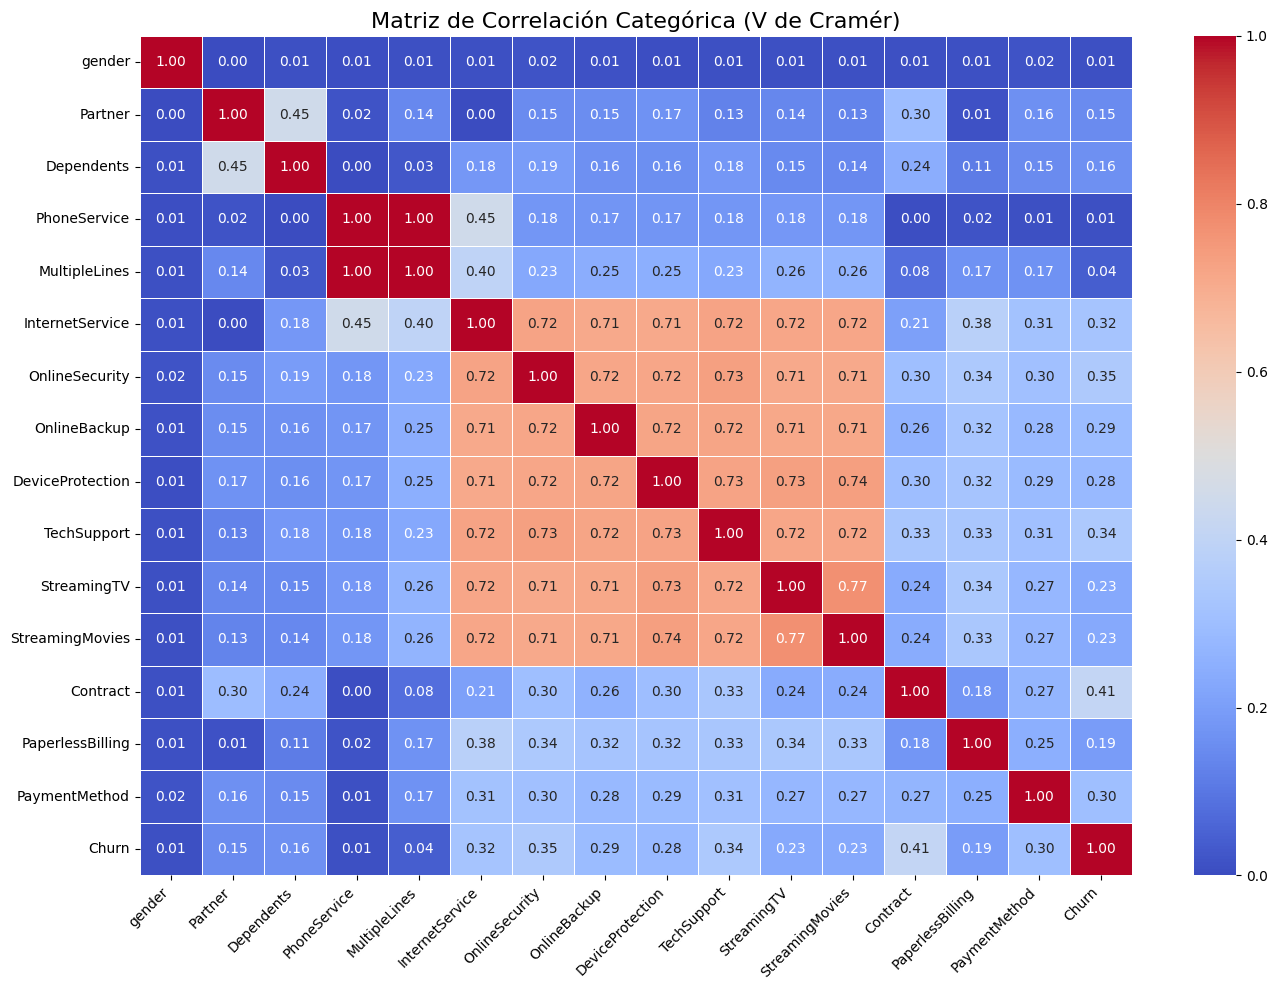

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations

# Función para calcular V de Cramér
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()  # Número total de observaciones
    k = min(confusion_matrix.shape)   # Número de categorías en la variable
    # max(0, ...) evita errores de redondeo matemático interno de Python
    return np.sqrt(max(0, chi2 / (n * (k - 1))))

# Crear una matriz vacía usando nuestra lista category_columns
matrix = pd.DataFrame(index=category_columns, columns=category_columns)

# Calcular V de Cramer para cada par de variables categóricas
for var1, var2 in combinations(category_columns, 2):
    contingency_table = pd.crosstab(data[var1], data[var2])
    value = cramers_v(contingency_table)
    matrix.loc[var1, var2] = value
    matrix.loc[var2, var1] = value

#Llenar la diagonal con 1s (correlación consigo misma)
#np.fill_diagonal(matrix.values, 1)

# Llenar la diagonal con 1s (Solución al error: usando Pandas nativo)
for col in category_columns:
    matrix.loc[col, col] = 1.0

# Convertir a tipo numérico (float)
matrix = matrix.astype(float)

# Visualizar la matriz como heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=0, vmax=1)
plt.title("Matriz de Correlación Categórica (V de Cramér)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusiones** del Análisis Categórica vs. Categórica:
- **Churn**: La categoría con el valor más alto es **Contract**, seguido de los **servicios**(OnlineSecurity = 0.35, TechSupport = 0.34, InternetService = 0.32). Los más irrelevantes son (**gender** = 0.01, **PhoneService** = 0.01)
- El bloque naranja (0.71-0.74) se debe a que estas variables cuentas con 1526 clientes que responden "No internet service" en bloque en todas ellas.
- En el bloque rojo (PhoneService vs MultipleLines = 1.00) si un cliente dice que no tiene teléfono, en la otra la respuesta es automática "No phone service".

# 3. Data Preparation

### 3.1 Selección de variables
Eliminación por baja relevancia predictiva:
- **gender**: La prueba de V de Cramér demostró una independencia casi total frente a la variable objetivo (0.01).
- **PhoneService**: Su nula capacidad predictiva sobre el Churn (0.01) sumada a su correlación perfecta (1.00) con la variable MultipleLines la hacen prescindible.
Eliminación por Multicolinealidad (Redundancia):
- **TotalCharges**: En la matriz de correlación de Pearson se evidenció una fuerte relación lineal (0.83) con tenure. Al ser un producto derivado del tiempo y la cuota mensual, se elimina para evitar inestabilidad en el futuro modelo predictivo.

In [13]:
# Elimnar columnas irelevantes persistiendo el cambio en el dataframe original
data.drop(columns=['gender','PhoneService','TotalCharges'], inplace=True)

### 3.2 Depuración de los Datos
- Ausencia de Nulos: Los únicos 11 valores nulos detectados en la fase inicial de Data Understanding pertenecían a la variable TotalCharges. Dado que esta variable ha sido eliminada por multicolinealidad en el paso anterior, el dataset actual está 100% libre de valores nulos. No se requiere aplicar técnicas de imputación.
- Tratamiento de Outliers: El análisis visual mediante Boxplots (Numérica vs. Target) demostró que las variables continuas restantes (tenure y MonthlyCharges) presentan distribuciones lógicas de negocio sin valores atípicos erróneos o desproporcionados.

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   str    
 2   Dependents        7043 non-null   str    
 3   tenure            7043 non-null   int64  
 4   MultipleLines     7043 non-null   str    
 5   InternetService   7043 non-null   str    
 6   OnlineSecurity    7043 non-null   str    
 7   OnlineBackup      7043 non-null   str    
 8   DeviceProtection  7043 non-null   str    
 9   TechSupport       7043 non-null   str    
 10  StreamingTV       7043 non-null   str    
 11  StreamingMovies   7043 non-null   str    
 12  Contract          7043 non-null   str    
 13  PaperlessBilling  7043 non-null   str    
 14  PaymentMethod     7043 non-null   str    
 15  MonthlyCharges    7043 non-null   float64
 16  Churn             7043 non-null   str    
dtypes: flo

### 3.3 Construcción de nuevas Variables

In [15]:
# Identificar las variables categóricas
category_columns = data.select_dtypes(include=['object', 'category', 'str']).columns
print("Variables categóricas: ", category_columns.values)

for column in category_columns:
    print(f"\nFrecuencia de la columna {column}:")
    print(data[column].value_counts())

Variables categóricas:  <ArrowStringArray>
[         'Partner',       'Dependents',    'MultipleLines',
  'InternetService',   'OnlineSecurity',     'OnlineBackup',
 'DeviceProtection',      'TechSupport',      'StreamingTV',
  'StreamingMovies',         'Contract', 'PaperlessBilling',
    'PaymentMethod',            'Churn']
Length: 14, dtype: str

Frecuencia de la columna Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Frecuencia de la columna Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Frecuencia de la columna MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Frecuencia de la columna InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Frecuencia de la columna OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dt

Para dejar el dataset preparado para el modelo de Regresión Logística, aplicamos dos transformaciones fundamentales:

1. Recategorización (Tratamiento de Multicolinealidad): Se han agrupado las categorías redundantes "No internet service" y "No phone service" bajo la etiqueta "No". Esto reduce el ruido y evita inestabilidades en el cálculo de los coeficientes del modelo.

2. One-Hot Encoding: Dado que todas las variables predictoras categóricas presentan baja cardinalidad, se ha descartado el Label Encoding para no introducir un falso orden matemático. Se aplica la codificación One-Hot, utilizando el parámetro drop_first=True para eliminar una categoría base (Dummy Trap) y asegurar que la matriz resultante sea invertible.

3. Codificación de la Variable Objetivo: La variable Churn se ha transformado a formato numérico binario (0 y 1).

In [16]:

# 1. FUNCIÓN DE DEPURACIÓN (Recategorización de valores)
def limpiar_redundancias(df):
    df_clean = df.copy()
    
    # Unificamos los "No internet service" a "No"
    columnas_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                         'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in columnas_internet:
        df_clean[col] = df_clean[col].replace({'No internet service': 'No'})
        
    # Unificamos los "No phone service" a "No"
    df_clean['MultipleLines'] = df_clean['MultipleLines'].replace({'No phone service': 'No'})
    
    return df_clean

# 2. FUNCIÓN DE TRANSFORMACIÓN (One-Hot Encoding)
def codificar_categoricas(df):
    df_encoded = df.copy()
    
    # Mapeamos el Target (Churn) a 0 y 1
    if 'Churn' in df_encoded.columns:
        df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})
        
    # Aplicamos One-Hot Encoding al resto (drop_first=True evita la multicolinealidad)
    df_encoded = pd.get_dummies(df_encoded, drop_first=True, dtype=int)
    
    return df_encoded

data = limpiar_redundancias(data)
data = codificar_categoricas(data)

data.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   Partner_Yes                            7043 non-null   int64  
 5   Dependents_Yes                         7043 non-null   int64  
 6   MultipleLines_Yes                      7043 non-null   int64  
 7   InternetService_Fiber optic            7043 non-null   int64  
 8   InternetService_No                     7043 non-null   int64  
 9   OnlineSecurity_Yes                     7043 non-null   int64  
 10  OnlineBackup_Yes                       7043 non-null   int64  
 11  DeviceProtectio

In [19]:
# Guardamos el dataframe limpio en la carpeta data
data.to_pickle("../data/telecom_churn_clean.pkl")